In [45]:
import pandas as pd
import numpy as np

In [46]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer


In [47]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [48]:
df.dropna(inplace=True)

In [49]:
df.shape

(714, 3)

In [50]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [51]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [52]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [53]:
X_train.sample(5)

,Age,Fare
811,39.0,24.150
822,38.0,0.000
682,20.0,9.225
580,25.0,30.000
577,39.0,55.900


In [54]:
clf = DecisionTreeClassifier()

In [55]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [56]:
accuracy_score(y_test,y_pred)

0.6363636363636364

In [57]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.634546165884194)

In [58]:
Kbin_age=KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')
Kbin_fare=KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')

In [59]:
trf = ColumnTransformer([
    ('first',Kbin_age,[0]),
     ('second',Kbin_fare,[1])
])

In [60]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


In [61]:
trf.named_transformers_['first'].n_bins_

array([15])

In [62]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
              32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])             ],
      dtype=object)

In [63]:
output =pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare':X_train_trf[:,1]
})

In [64]:
output['age_labels']=pd.cut(x=X_train['Age'],
                           bins=trf.named_transformers_['first'].bin_edges_[0].tolist())

output['fare_labels']=pd.cut(x=X_train['Fare'],
                           bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [65]:
output.sample(5)

,age,age_trf,fare,age_labels,fare_labels
614,35.0,10.0,3.0,"(32.0, 35.0]","(7.896, 8.158]"
86,16.0,2.0,11.0,"(6.0, 16.0]","(31.275, 51.479]"
789,46.0,12.0,13.0,"(42.0, 47.0]","(76.292, 108.9]"
178,30.0,8.0,6.0,"(28.0, 30.0]","(10.5, 13.0]"
130,33.0,9.0,3.0,"(32.0, 35.0]","(7.775, 7.896]"


In [66]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf, y_train)
y_pred2 = clf.predict(X_test_trf)

In [67]:
accuracy_score(y_test,y_pred2)

0.6363636363636364

In [68]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


np.float64(0.6359350547730829)

C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


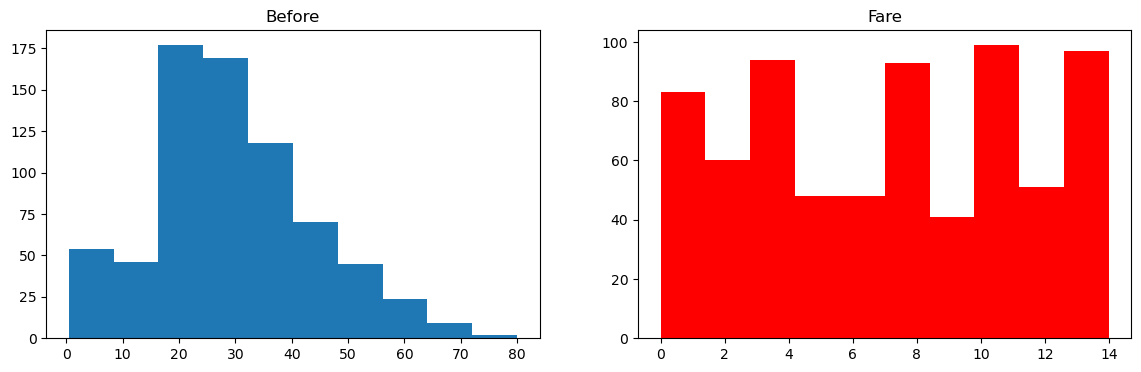

In [74]:
def discretize(bins,strategy):
    
    Kbin_age=KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    Kbin_fare=KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)

    trf = ColumnTransformer([
    ('first',Kbin_age,[0]),
     ('second',Kbin_fare,[1])
])

X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

plt.figure(figsize=(14,4))
plt.subplot(121)
plt.hist(X['Age'])
plt.title("Before")

plt.subplot(122)
plt.hist(X_trf[:,1],color='red')
plt.title("Fare")

plt.show()
discretize(10,'uniform')

In [71]:
discretize(10,'quantile')